# SMOTE (Synthetic Minority Oversampling Technique)

SMOTE is an oversampling technique where synthetic samples are generated for the minority class by interpolating between nearby minority examples. It helps reduce overfitting compared to simple random oversampling.

## Class Imbalance

In imbalanced binary classification, one class is the **majority** class and the other is the **minority** class (for example, fraud detection).

Typical baseline methods:
- Oversampling minority class
- Undersampling majority class

Other advanced techniques include:
- ADASYN
- Borderline-SMOTE
- KMeansSMOTE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

data_path = Path('credit_dataset.csv')
if not data_path.exists():
    data_path = Path('exp08/credit_dataset.csv')

df = pd.read_csv(data_path)
df.head()

,Unnamed: 0,ID,GENDER,CAR,REALITY,NO_OF_CHILD,INCOME,INCOME_TYPE,EDUCATION_TYPE,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET
0,0,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,2.0,29,59,3,0
1,1,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8,0
2,2,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8,0
3,3,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8,0
4,4,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8,0


## Exploring Data Distribution

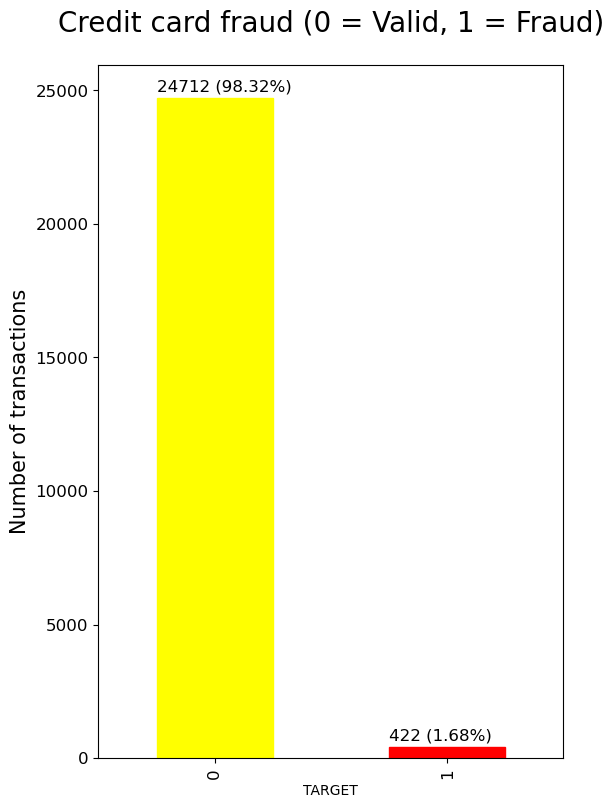

In [3]:
ax = df['TARGET'].value_counts().plot(kind='bar', figsize=(6, 9), fontsize=12)
ax.set_title('Credit card fraud (0 = Valid, 1 = Fraud)', size=20, pad=24)
ax.set_ylabel('Number of transactions', fontsize=15)

N = len(df)
colors = ['yellow', 'red']

for idx, patch in enumerate(ax.patches):
    ax.text(
        patch.get_x(),
        patch.get_height() + 240,
        f"{int(patch.get_height())} ({round(patch.get_height() * 100 / N, 2)}%)",
        fontsize=12
    )
    patch.set_color(colors[idx])

plt.show()

## Data Preparation

In [4]:
work_df = df.copy()

work_df['GENDER'] = [0 if x == 'M' else 1 for x in work_df['GENDER']]
work_df['CAR'] = [1 if x == 'Y' else 0 for x in work_df['CAR']]
work_df['REALITY'] = [1 if x == 'Y' else 0 for x in work_df['REALITY']]

dummy_income_type = pd.get_dummies(work_df['INCOME_TYPE'], prefix='INC_TYPE', drop_first=True)
dummy_edu_type = pd.get_dummies(work_df['EDUCATION_TYPE'], prefix='EDU_TYPE', drop_first=True)
dummy_family_type = pd.get_dummies(work_df['FAMILY_TYPE'], prefix='FAM_TYPE', drop_first=True)
dummy_house_type = pd.get_dummies(work_df['HOUSE_TYPE'], prefix='HOUSE_TYPE', drop_first=True)

to_drop = ['Unnamed: 0', 'ID', 'FLAG_MOBIL', 'EDUCATION_TYPE', 'FAMILY_TYPE', 'INCOME_TYPE', 'HOUSE_TYPE']
work_df.drop(to_drop, axis=1, inplace=True)

merged = pd.concat([work_df, dummy_income_type, dummy_edu_type, dummy_family_type, dummy_house_type], axis=1)
merged.head()

,GENDER,CAR,REALITY,NO_OF_CHILD,INCOME,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,...,EDU_TYPE_Secondary / secondary special,FAM_TYPE_Married,FAM_TYPE_Separated,FAM_TYPE_Single / not married,FAM_TYPE_Widow,HOUSE_TYPE_House / apartment,HOUSE_TYPE_Municipal apartment,HOUSE_TYPE_Office apartment,HOUSE_TYPE_Rented apartment,HOUSE_TYPE_With parents
0,0,1,1,0,112500.0,0,0,0,2.0,29,...,True,True,False,False,False,True,False,False,False,False
1,1,0,1,0,270000.0,0,1,1,1.0,4,...,True,False,False,True,False,True,False,False,False,False
2,1,0,1,0,270000.0,0,1,1,1.0,26,...,True,False,False,True,False,True,False,False,False,False
3,1,0,1,0,270000.0,0,1,1,1.0,26,...,True,False,False,True,False,True,False,False,False,False
4,1,0,1,0,270000.0,0,1,1,1.0,38,...,True,False,False,True,False,True,False,False,False,False


In [5]:
from sklearn.preprocessing import MinMaxScaler

to_scale = [col for col in merged.columns if merged[col].max() > 1]
mms = MinMaxScaler()
scaled = mms.fit_transform(merged[to_scale])
scaled = pd.DataFrame(scaled, columns=to_scale)

for col in scaled.columns:
    merged[col] = scaled[col]

merged.head()

,GENDER,CAR,REALITY,NO_OF_CHILD,INCOME,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,...,EDU_TYPE_Secondary / secondary special,FAM_TYPE_Married,FAM_TYPE_Separated,FAM_TYPE_Single / not married,FAM_TYPE_Widow,HOUSE_TYPE_House / apartment,HOUSE_TYPE_Municipal apartment,HOUSE_TYPE_Office apartment,HOUSE_TYPE_Rented apartment,HOUSE_TYPE_With parents
0,0,1,1,0.0,0.055233,0,0,0,0.052632,0.483333,...,True,True,False,False,False,True,False,False,False,False
1,1,0,1,0.0,0.156977,0,1,1,0.000000,0.066667,...,True,False,False,True,False,True,False,False,False,False
2,1,0,1,0.0,0.156977,0,1,1,0.000000,0.433333,...,True,False,False,True,False,True,False,False,False,False
3,1,0,1,0.0,0.156977,0,1,1,0.000000,0.433333,...,True,False,False,True,False,True,False,False,False,False
4,1,0,1,0.0,0.156977,0,1,1,0.000000,0.633333,...,True,False,False,True,False,True,False,False,False,False


## Ignoring Data Imbalance (Baseline)

% Positive class in Train = 1.69
% Positive class in Test  = 1.65
Accuracy = 0.98
Recall = 0.09



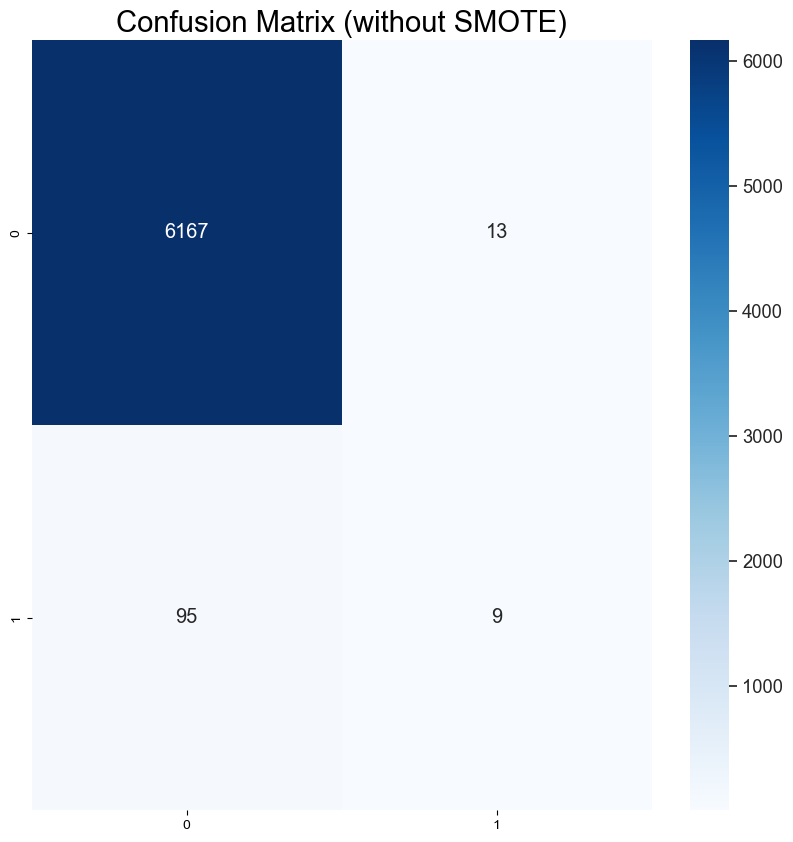

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

X = merged.drop('TARGET', axis=1)
y = merged['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"% Positive class in Train = {np.round(y_train.value_counts(normalize=True)[1] * 100, 2)}")
print(f"% Positive class in Test  = {np.round(y_test.value_counts(normalize=True)[1] * 100, 2)}")

model = RandomForestClassifier(random_state=78)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"Accuracy = {accuracy_score(y_test, preds):.2f}\nRecall = {recall_score(y_test, preds):.2f}\n")

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 10))
plt.title('Confusion Matrix (without SMOTE)', size=21)
sns.set(font_scale=1.2)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.show()

## Adding SMOTE

In [7]:
# If needed: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=78)
X_sm, y_sm = sm.fit_resample(X, y)

print(f"Shape of X before SMOTE: {X.shape}")
print(f"Shape of X after SMOTE: {X_sm.shape}")
print('\nBalance of positive and negative classes (%):')
display(y_sm.value_counts(normalize=True) * 100)

Shape of X before SMOTE: (25134, 29)
Shape of X after SMOTE: (49424, 29)

Balance of positive and negative classes (%):


TARGET
0    50.0
1    50.0
Name: proportion, dtype: float64

Accuracy = 0.99
Recall = 0.99



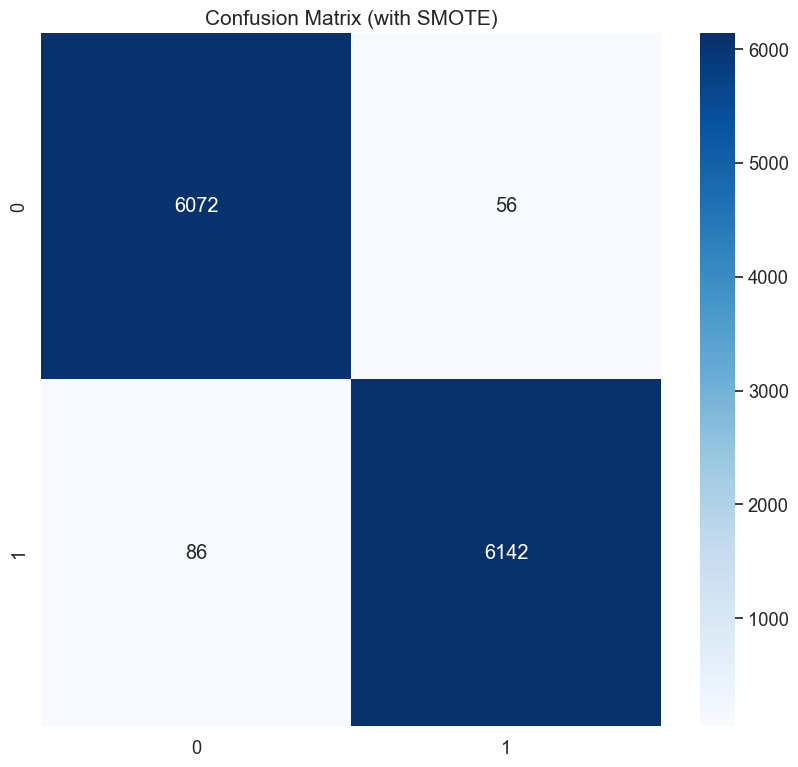

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sm, y_sm, test_size=0.25, random_state=42
)

model_sm = RandomForestClassifier(random_state=42)
model_sm.fit(X_train, y_train)
preds_sm = model_sm.predict(X_test)

print(f"Accuracy = {accuracy_score(y_test, preds_sm):.2f}\nRecall = {recall_score(y_test, preds_sm):.2f}\n")

cm_sm = confusion_matrix(y_test, preds_sm)
plt.figure(figsize=(10, 9))
plt.title('Confusion Matrix (with SMOTE)', size=15)
sns.heatmap(cm_sm, annot=True, cmap='Blues', fmt='g')
plt.show()

## Conclusion

Without SMOTE, the model can show high overall accuracy but poor minority-class recall, making it weak for fraud detection.

After applying SMOTE, class balance improves, and recall for fraud cases improves substantially, making the model more useful for imbalanced classification tasks.